1st column is the acceleration data in the X axis measured by the sensor ADXL345.
2nd column is the acceleration data in the Y axis measured by the sensor ADXL345.
3rd column is the acceleration data in the Z axis measured by the sensor ADXL345.

4th column is the rotation data in the X axis measured by the sensor ITG3200.
5th column is the rotation data in the Y axis measured by the sensor ITG3200.
6th column is the rotation data in the Z axis measured by the sensor ITG3200.

7th column is the acceleration data in the X axis measured by the sensor MMA8451Q.
8th column is the acceleration data in the Y axis measured by the sensor MMA8451Q.
9th column is the acceleration data in the Z axis measured by the sensor MMA8451Q.

File name format:
**<ADL OR FALL_CODE>_<SUBJECT_ID>_<TRIAL_NO>.txt**

**Activities of Daily Living (ADL):**

<!-- <div align="center"> -->

| Code | Activity                                                                                 | Trials | Duration |
|:----:|------------------------------------------------------------------------------------------|:------:|:--------:|
| D01  | Walking slowly                                                                           | 1      | 100s     |
| D02  | Walking quickly                                                                          | 1      | 100s     |
| D03  | Jogging slowly                                                                           | 1      | 100s     |
| D04  | Jogging quickly                                                                          | 1      | 100s     |
| D05  | Walking upstairs and downstairs slowly                                                   | 5      | 25s      |
| D06  | Walking upstairs and downstairs quickly                                                  | 5      | 25s      |
| D07  | Slowly sit in a half height chair, wait a moment, and up slowly                          | 5      | 12s      |
| D08  | Quickly sit in a half height chair, wait a moment, and up quickly                        | 5      | 12s      |
| D09  | Slowly sit in a low height chair, wait a moment, and up slowly                           | 5      | 12s      |
| D10  | Quickly sit in a low height chair, wait a moment, and up quickly                         | 5      | 12s      |
| D11  | Sitting a moment, trying to get up, and collapse into a chair                            | 5      | 12s      |
| D12  | Sitting a moment, lying slowly, wait a moment, and sit again                             | 5      | 12s      |
| D13  | Sitting a moment, lying quickly, wait a moment, and sit again                            | 5      | 12s      |
| D14  | Being on one's back change to lateral position, wait a moment, and change to one's back  | 5      | 12s      |
| D15  | Standing, slowly bending at knees, and getting up                                        | 5      | 12s      |
| D16  | Standing, slowly bending without bending knees, and getting up                           | 5      | 12s      |
| D17  | Standing, get into a car, remain seated and get out of the car                           | 5      | 25s      |
| D18  | Stumble while walking                                                                    | 5      | 12s      |
| D19  | Gently jump without falling (trying to reach a high object)                              | 5      | 12s      |


Falls:

| Code | Activity                                                                                 | Trials | Duration |
|:----:|------------------------------------------------------------------------------------------|:------:|:--------:|
| F01  | Fall forward while walking caused by a slip                                              | 5      | 15s      |
| F02  | Fall backward while walking caused by a slip                                             | 5      | 15s      |
| F03  | Lateral fall while walking caused by a slip                                              | 5      | 15s      |
| F04  | Fall forward while walking caused by a trip                                              | 5      | 15s      |
| F05  | Fall forward while jogging caused by a trip                                              | 5      | 15s      |
| F06  | Vertical fall while walking caused by fainting                                           | 5      | 15s      |
| F07  | Fall while walking, with use of hands in a table to dampen fall, caused by fainting      | 5      | 15s      |
| F08  | Fall forward when trying to get up                                                       | 5      | 15s      |
| F09  | Lateral fall when trying to get up                                                       | 5      | 15s      |
| F10  | Fall forward when trying to sit down                                                     | 5      | 15s      |
| F11  | Fall backward when trying to sit down                                                    | 5      | 15s      |
| F12  | Lateral fall when trying to sit down                                                     | 5      | 15s      |
| F13  | Fall forward while sitting, caused by fainting or falling asleep                         | 5      | 15s      |
| F14  | Fall backward while sitting, caused by fainting or falling asleep                        | 5      | 15s      |
| F15  | Lateral fall while sitting, caused by fainting or falling asleep                         | 5      | 15s      |
<!-- </div> -->

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import os
# import zipfile
import functions as fn
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Path to zip file
zip_file_path = 'DataSet/SisFall_dataset.zip'

# Base path to the dataset folder structure *inside* the zip file
base_path = 'SisFall_dataset'

# Create list of folder names (SA01 to SA23 and SE01 to SE15)
subject_ids = [f'SA{str(i).zfill(2)}' for i in range(1, 24)] + [f'SE{str(i).zfill(2)}' for i in range(1, 16)]

# all_data, all_labels, activity_code_list, adls, falls = fn.read_file(base_path, subject_ids)
all_data, all_labels, activity_code_list, file_name_list, adls, falls = fn.read_zip(zip_file_path, base_path, subject_ids)

print(f'number of total readings: {len(all_data)}')
print(f'number of total labels: {len(all_labels)}')
print(f'number of total activity codes: {len(activity_code_list)}')
print(f'number of total file names: {len(file_name_list)}')
print('------------------------------------------')
print(f'number of total ADL data: {len(adls)}')
print(f'number of total Fall data: {len(falls)}')
print('------------------------------------------')
# print number of unique labels and their counts
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("Unique labels and their counts:")
for label, count in zip(unique_labels, counts):
    print(f"{label}: {count}")

# create a dictionary to map activity codes to real-world activities
activity_mapping = {
    "D01": "Walking slowly",
    "D02": "Walking quickly",
    "D03": "Jogging slowly",
    "D04": "Jogging quickly",
    "D05": "Walking upstairs and downstairs slowly",
    "D06": "Walking upstairs and downstairs quickly",
    "D07": "Slowly sit in a half height chair, wait a moment, and up slowly",
    "D08": "Quickly sit in a half height chair, wait a moment, and up quickly",
    "D09": "Slowly sit in a low height chair, wait a moment, and up slowly",
    "D10": "Quickly sit in a low height chair, wait a moment, and up quickly",
    "D11": "Sitting a moment, trying to get up, and collapse into a chair ",
    "D12": "Sitting a moment, lying slowly, wait a moment, and sit again",
    "D13": "Sitting a moment, lying quickly, wait a moment, and sit again",
    "D14": "Being on one's back change to lateral position, wait a moment, and change to one's back",
    "D15": "Standing, slowly bending at knees, and getting up",
    "D16": "Standing, slowly bending without bending knees, and getting up",
    "D17": "Standing, get into a car, remain seated and get out of the car",
    "D18": "Stumble while walking",
    "D19": "Gently jump without falling (trying to reach a high object)",
    "F01": "Fall forward while walking caused by a slip",
    "F02": "Fall backward while walking caused by a slip",
    "F03": "Lateral fall while walking caused by a slip",
    "F04": "Fall forward while walking caused by a trip",
    "F05": "Fall backward while walking caused by a trip",
    "F06": "Vertical fall while walking caused by fainting",
    "F07": "Fall while walking, with use of hands in a table to dampen fall, caused by fainting",
    "F08": "Fall forward when trying to get up",
    "F09": "Lateral fall when trying to get up",
    "F10": "Fall forward when trying to sit down",
    "F11": "Fall backward when trying to sit down",
    "F12": "Lateral fall when trying to sit down",
    "F13": "Fall forward while sitting, caused by fainting or falling asleep",
    "F14": "Fall backward while sitting, caused by fainting or falling asleep",
    "F15": "Lateral fall while sitting, caused by fainting or falling asleep",
}



Progress: 4505/4505 files processed
Total files processed: 4505 ✅
Total ADL labels: 2707 ✅
Total Fall labels: 1798 ✅
number of total readings: 4505
number of total labels: 4505
number of total activity codes: 4505
number of total file names: 4505
------------------------------------------
number of total ADL data: 2707
number of total Fall data: 1798
------------------------------------------
Unique labels and their counts:
ADL: 2707
Fall: 1798


In [6]:

activity_data = {}

for code in activity_mapping.keys():
    indices = [i for i, act_code in enumerate(activity_code_list) if act_code == code]
    data_list = [all_data[i] for i in indices]
    file_names_list = [file_name_list[i] for i in indices]
    shapes_list = [d.shape for d in data_list]
    
    activity_data[code] = {
        "data": data_list,
        "file_names": file_names_list,
        "shapes": shapes_list
    }

In [7]:
for code, info in activity_data.items():
    print(f"{code}: {info['shapes']}")

D01: [(6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19997), (6, 19999), (6, 19999), (6, 19999), (6, 35999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19985), (6, 19999), (6, 19999), (6, 19998), (6, 19999), (6, 19999), (6, 19999)]
D02: [(6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 19999), (6, 20000), (6, 20000), (6, 19999), (6, 19999), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 19999), (6, 20000), (6, 19999), (6, 20000), (6, 36000), (6, 20000), (6, 20001), (6, 20000), (6, 20001), (6, 20000), (6, 19999), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000)]
D03: [(6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000)

In [8]:
processed_activities = {}

for code, info in activity_data.items():
    data_list = info["data"]
    file_names_list = info["file_names"]

    # Example processing: split_and_add for D01-D04, idle_remover+split_and_center for D05, etc.
    # You may want to adjust these per your actual processing logic.

    if code in ["D01", "D02", "D03", "D04"]:
        # Use split_and_add
        processed_data, processed_file_names, processed_activity_codes = fn.split_and_add(data_list, 800, file_names_list)
        processed_activities[code] = {
            "data": processed_data,
            "file_names": processed_file_names,
            "activity_codes": processed_activity_codes
        }
    elif code == "D05":
        # idle_remover + split_and_center
        cleaned_data = fn.idle_remover(data_list, 200, 30, mode='gyro')
        
        data_1, data_2 = fn.split_and_center(cleaned_data, 800)
        
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D06":
        cleaned_data = fn.idle_remover(data_list, 150, 30, mode='acc')
        data_1, data_2 = fn.split_and_center(cleaned_data, 800)
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D07":
        # extract_from_high_amp_segments
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.3, 700, 200, 800, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D08":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.14, 500, 100, 500, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D09":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.1, 700, 100, 700, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D10":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.1, 500, 100, 500, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D11":
        data = fn.keep_from_peak(data_list, 400)
        processed_activities[code] = {
            "data": data
        }
    elif code == "D12":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.2, 800, 200, 800, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D13":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.2, 500, 50, 500, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D14":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.15, 600, 100, 600, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D15":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 250, 250, 0.2, 700, 200, 800, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D16":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.15, 700, 200, 800, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D17":
        # Remove first 300 samples from each signal before processing
        trimmed_data = [d[:, 300:] for d in data_list]
        data_1, data_2 = fn.extract_from_high_amp_segments(trimmed_data, 300, 300, 0.3, 1000, 200, 1000, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D18":
        data = fn.keep_from_peak(data_list, 400)
        processed_activities[code] = {
            "data": data
        }
    elif code == "D19":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.2, 400, 150, 500, "acc")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    else:
        # For F01-F15 and any other codes, you can add similar processing as needed
        processed_activities[code] = {
            "data": data_list,
            "file_names": file_names_list
        }


number of new D01 data: 932 with shape: (932, 6, 800), file_names :932, activities: 932 
number of new D02 data: 964 with shape: (964, 6, 800), file_names :964, activities: 964 
number of new D03 data: 965 with shape: (965, 6, 800), file_names :965, activities: 965 
number of new D04 data: 915 with shape: (915, 6, 800), file_names :915, activities: 915 
190 files processed, Min length: 2800, Max length: 5000
190 files processed, Min length: 800, Max length: 800
190 files processed, Min length: 800, Max length: 800
118 files processed, Min length: 1350, Max length: 2550
118 files processed, Min length: 800, Max length: 800
118 files processed, Min length: 800, Max length: 800
Number of features extracted (f4): 190
190 files processed using scale: 0.3 
Min1: 800, Max1: 800 
Min2: 500, Max2: 800
Number of features extracted (f4): 190
190 files processed using scale: 0.14 
Min1: 500, Max1: 500 
Min2: 500, Max2: 500
Number of features extracted (f4): 185
185 files processed using scale: 0.1

In [26]:
processed_activities['D01']['data'][2]

array([[  17,   15,    1, ...,   16,   16,   15],
       [-179, -174, -176, ..., -241, -240, -236],
       [ -99,  -90,  -81, ...,  -31,  -32,  -35],
       [ -18,  -53,  -84, ..., -133, -121, -106],
       [-504, -568, -613, ...,  652,  669,  686],
       [-352, -306, -271, ...,  372,  360,  347]])

In [12]:
# Extract first 3 rows (accelerometer axes) from all data arrays in processed_activities
accelerometer_data = {}

for code, info in processed_activities.items():
    accelerometer_data[code] = {}
    
    # Handle different data structures based on the keys present
    if "data" in info and "data_1" not in info and "data_2" not in info:
        # Single data array (D01-D04, D11, D18, and default cases)
        data_arrays = info["data"]
        
        # Extract first 3 rows from each array in the list
        accel_arrays = []
        for array in data_arrays:
            if array.shape[0] >= 3:  # Ensure array has at least 3 rows
                accel_arrays.append(array[:3, :])  # Take first 3 rows (accelerometer axes)
            else:
                accel_arrays.append(array)  # Keep as is if less than 3 rows
        
        accelerometer_data[code]["data"] = accel_arrays
    
    elif "data_1" in info and "data_2" in info:
        # Split data structure (D05-D10, D12-D17, D19)
        
        # Process data_1
        data_1_arrays = info["data_1"]
        accel_data_1 = []
        for array in data_1_arrays:
            if array.shape[0] >= 3:
                accel_data_1.append(array[:3, :])
            else:
                accel_data_1.append(array)
        accelerometer_data[code]["data_1"] = accel_data_1
        
        # Process data_2
        data_2_arrays = info["data_2"]
        accel_data_2 = []
        for array in data_2_arrays:
            if array.shape[0] >= 3:
                accel_data_2.append(array[:3, :])
            else:
                accel_data_2.append(array)
        accelerometer_data[code]["data_2"] = accel_data_2

# Print summary of extracted data
print("Accelerometer data extraction summary:")
print(f"Total activity codes processed: {len(accelerometer_data)}")

for code, data in accelerometer_data.items():
    if "data" in data:
        print(f"{code}: {len(data['data'])} arrays, shapes: {[arr.shape for arr in data['data'][:3]]}")
    elif "data_1" in data and "data_2" in data:
        print(f"{code}: data_1 has {len(data['data_1'])} arrays, data_2 has {len(data['data_2'])} arrays")
        if data['data_1']:
            print(f"  data_1 sample shapes: {[arr.shape for arr in data['data_1'][:3]]}")
        if data['data_2']:
            print(f"  data_2 sample shapes: {[arr.shape for arr in data['data_2'][:3]]}")

Accelerometer data extraction summary:
Total activity codes processed: 34
D01: 932 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D02: 964 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D03: 965 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D04: 915 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D05: data_1 has 190 arrays, data_2 has 190 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D06: data_1 has 118 arrays, data_2 has 118 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D07: data_1 has 190 arrays, data_2 has 190 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D08: data_1 has 190 arrays, data_2 has 190 arrays
  data_1 sample shapes: [(3, 500), (3, 500), (3, 500)]
  data_2 sample shapes: [(3, 500), (3, 500), (3, 500)]
D09: data_1 has 185 arrays, data_2 has 185 arrays
  data_1 sam

In [3]:
from scripts import classifiers
import sisfall_utils as sisfall
from scripts.uma import transform_uma_to_sisfall_format, uma_search_csv_files

files = uma_search_csv_files('output_uma')
uma_df = transform_uma_to_sisfall_format(files)


sisfall_df = sisfall.load()


# Load UMA file


# sisfall_cv_df, sisfall_aggr = classifiers.cross_validate(
#   sisfall, df=sisfall_df, model_type='tabular')



In [4]:
sisfall_df

,SubjectID,Activity,Duration (s),Acc,Target,accel_g
0,SA01,Walking slowly,100,"[[76.0, -697.0, -279.0], [48.0, -675.0, -254.0...",0,"[0.18927020851410026, 0.15821587497215417, 0.1..."
1,SA01,Walking quickly,100,"[[20.0, -1042.0, 167.0], [19.0, -1031.0, 92.0]...",0,"[0.6099537819574752, 0.5902114847627233, 0.556..."
2,SA01,Jogging slowly,100,"[[-163.0, -296.0, -111.0], [-163.0, -257.0, -1...",0,"[0.32045412090140996, 0.2865611365470213, 0.23..."
3,SA01,Jogging quickly,100,"[[353.0, -1625.0, -299.0], [278.0, -1629.0, -2...",0,"[1.6148517609956075, 1.5941249822514771, 1.619..."
4,SA01,Walking upstairs and downstairs slowly,25,"[[-40.0, -1006.0, 42.0], [-41.0, -999.0, 43.0]...",0,"[0.37092057575475545, 0.36417704659079, 0.3718..."
...,...,...,...,...,...,...
4500,SE15,Standing get into a car remain seated and get ...,25,"[[30.0, -861.0, -549.0], [33.0, -861.0, -548.0...",0,"[0.2060613158653406, 0.20562722686774426, 0.21..."
4501,SE15,Standing get into a car remain seated and get ...,25,"[[-14.0, -868.0, -546.0], [-18.0, -867.0, -543...",0,"[0.18590992720245458, 0.18358662215531674, 0.1..."
4502,SE15,Standing get into a car remain seated and get ...,25,"[[14.0, -841.0, -598.0], [10.0, -835.0, -605.0...",0,"[0.2579857129818103, 0.25716639523596874, 0.25..."
4503,SE15,Standing get into a car remain seated and get ...,25,"[[-22.0, -847.0, -588.0], [-26.0, -845.0, -575...",0,"[0.31957697626119763, 0.3108700128297103, 0.31..."


In [5]:
uma_df

,SubjectID,Activity,Duration (s),Acc,Target,accel_g
0,SA15,Activity14,14.7,"[[0.9306640625, 0.061279296875, 0.35302734375]...",0,"[[0.9306640625, 0.061279296875, 0.35302734375]..."
1,SA15,Activity14,14.7,"[[0.98681640625, 0.2119140625, 0.2099609375], ...",0,"[[0.98681640625, 0.2119140625, 0.2099609375], ..."
2,SA15,Activity14,14.9,"[[0.926513671875, 0.143798828125, 0.4384765625...",0,"[[0.926513671875, 0.143798828125, 0.4384765625..."
3,SA15,Activity14,14.8,"[[0.9326171875, 0.1474609375, 0.3662109375], [...",0,"[[0.9326171875, 0.1474609375, 0.3662109375], [..."
4,SA15,Activity13,14.9,"[[1.001953125, 0.056396484375, 0.349853515625]...",0,"[[1.001953125, 0.056396484375, 0.349853515625]..."
...,...,...,...,...,...,...
673,SA09,Activity7,14.8,"[[-0.92529296875, -0.087158203125, 0.229003906...",0,"[[-0.92529296875, -0.087158203125, 0.229003906..."
674,SA09,Activity7,14.9,"[[-0.916015625, -0.17626953125, 0.280029296875...",0,"[[-0.916015625, -0.17626953125, 0.280029296875..."
675,SA09,Activity9,14.8,"[[-0.86572265625, 0.340576171875, 0.1716308593...",0,"[[-0.86572265625, 0.340576171875, 0.1716308593..."
676,SA09,Activity9,14.8,"[[-0.873291015625, 0.28955078125, 0.2053222656...",0,"[[-0.873291015625, 0.28955078125, 0.2053222656..."


=== TRAINING MODELS ===
Train subjects: 31, Test subjects: 7
Train set: X: (9947, 1400), y: (9947,) ([ADLs, Falls]: [8929 1018])
Test set: X: (2096, 1400), y: (2096,) ([ADLs, Falls]: [1914  182])
NaN values in training set: 10
NaN values in test set: 0
Imputing NaN values using strategy: knn

=== ExtraTreesClassifier ===
Train AUC: 1.000
Test AUC: 0.994
Overfitting gap: 0.006
✅ Good generalization

=== RandomForestClassifier ===
Train AUC: 1.000
Test AUC: 0.983
Overfitting gap: 0.017
✅ Good generalization

=== CONFUSION MATRICES ===


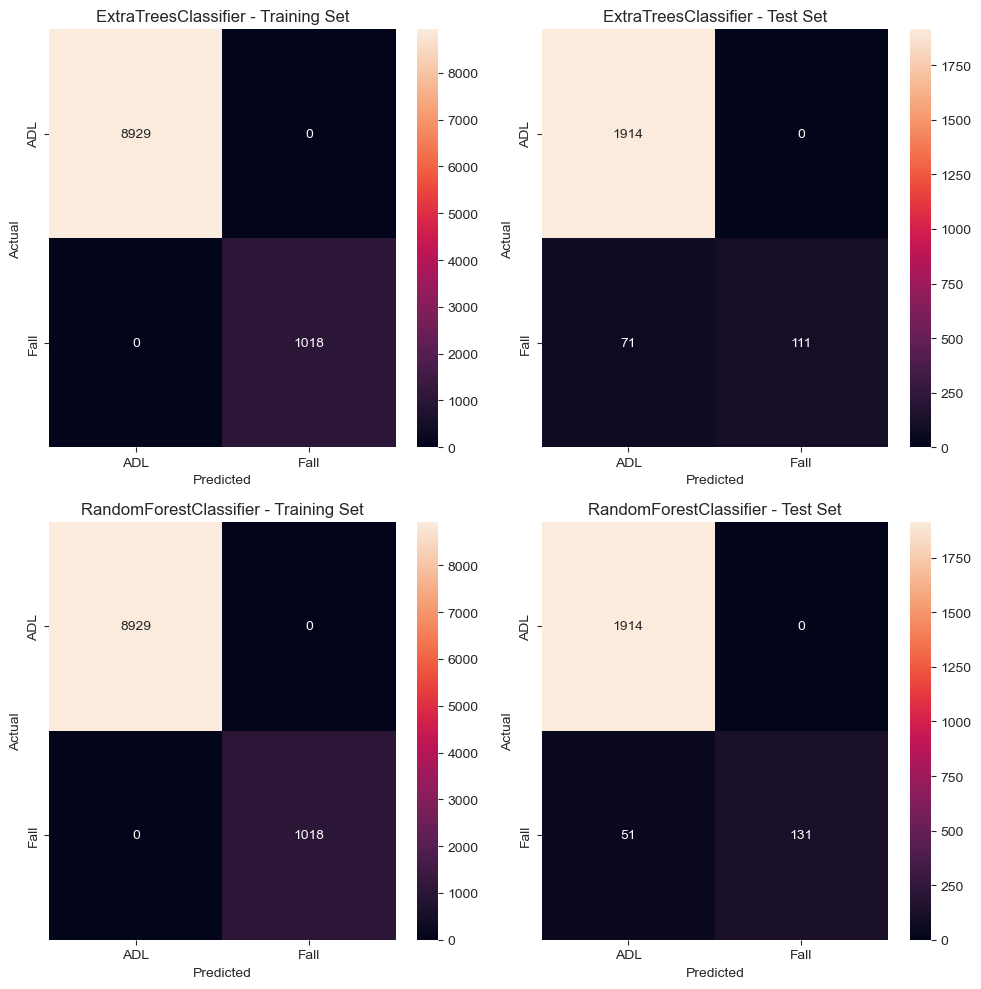


=== LEARNING CURVES ===


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


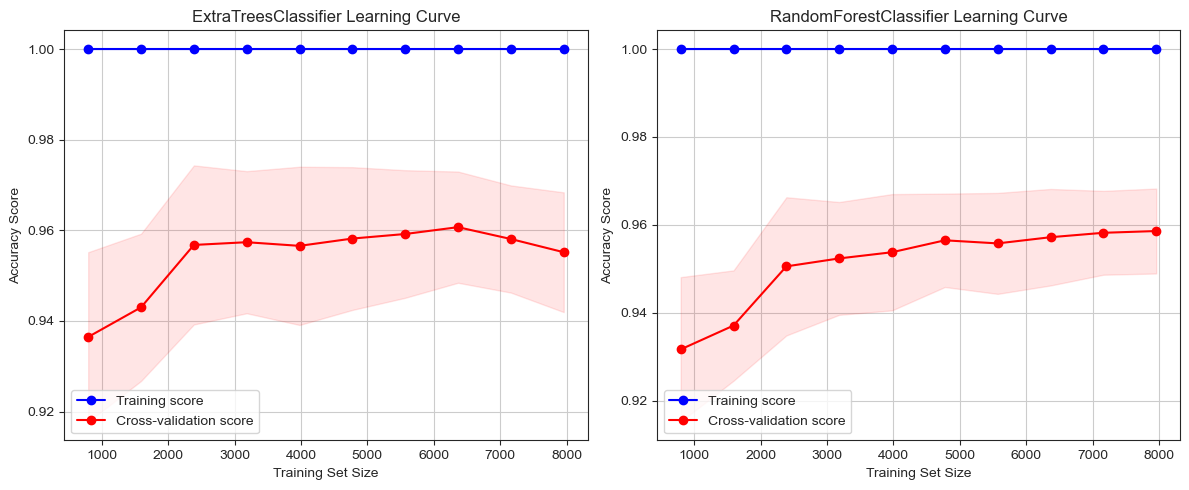


=== FEATURE IMPORTANCE ===


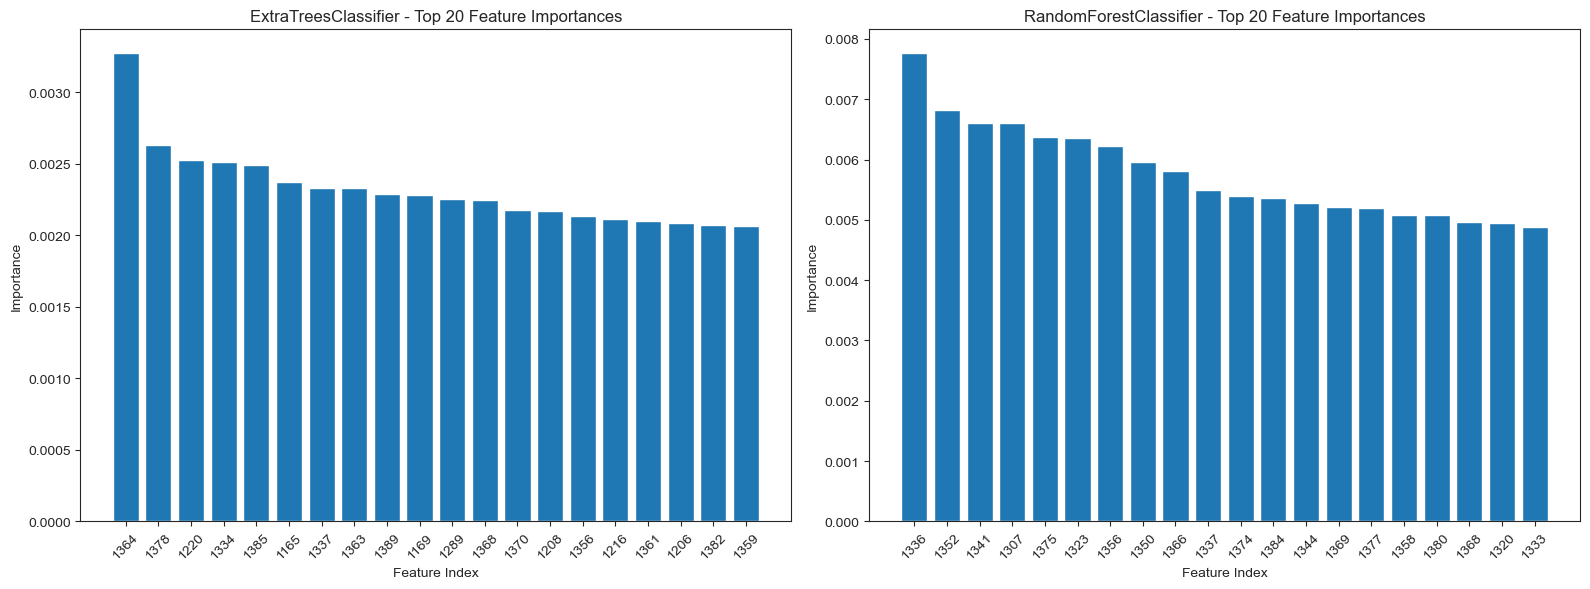


=== DETAILED CLASSIFICATION REPORTS ===

ExtraTreesClassifier - Test Set Classification Report:
              precision    recall  f1-score   support

         ADL       0.96      1.00      0.98      1914
        Fall       1.00      0.61      0.76       182

    accuracy                           0.97      2096
   macro avg       0.98      0.80      0.87      2096
weighted avg       0.97      0.97      0.96      2096


RandomForestClassifier - Test Set Classification Report:
              precision    recall  f1-score   support

         ADL       0.97      1.00      0.99      1914
        Fall       1.00      0.72      0.84       182

    accuracy                           0.98      2096
   macro avg       0.99      0.86      0.91      2096
weighted avg       0.98      0.98      0.97      2096



{'ExtraTreesClassifier': {'model': Pipeline(steps=[('imputer', KNNImputer()),
                  ('classifier', ExtraTreesClassifier(random_state=9))]),
  'train_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'test_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'train_auc': 1.0,
  'test_auc': 0.9942413907931149,
  'overfitting_gap': 0.00575860920688509},
 'RandomForestClassifier': {'model': Pipeline(steps=[('imputer', KNNImputer()),
                  ('classifier', RandomForestClassifier(random_state=9))]),
  'train_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'test_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'train_auc': 1.0,
  'test_auc': 0.982676805952668,
  'overfitting_gap': 0.017323194047331958}}

In [6]:
from scripts.new_classifier_utils import full_model_analysis


results = full_model_analysis(sisfall, sisfall_df, handle_nans='impute', imputation_strategy='knn')
results

In [38]:
# One sample from sisfall
print("sisfall accel_g[0]:", type(sisfall_df.loc[0, 'accel_g']), np.array(sisfall_df.loc[0, 'accel_g']).shape)

# One sample from uma
print("uma_df accel_g[0]:", type(uma_df.loc[0, 'accel_g']), np.array(uma_df.loc[0, 'accel_g']).shape)


sisfall accel_g[0]: <class 'numpy.ndarray'> (20000,)
uma_df accel_g[0]: <class 'list'> (289, 3)


In [39]:
for i, row in uma_df.iterrows():
    accel_array = np.array(row['accel_g'])
    print(f"Row {i} - shape: {accel_array.shape}, target: {row['Target']}")


Row 0 - shape: (289, 3), target: 0
Row 1 - shape: (267, 3), target: 0
Row 2 - shape: (300, 3), target: 0
Row 3 - shape: (300, 3), target: 0
Row 4 - shape: (300, 3), target: 0
Row 5 - shape: (299, 3), target: 0
Row 6 - shape: (300, 3), target: 0
Row 7 - shape: (300, 3), target: 0
Row 8 - shape: (300, 3), target: 0
Row 9 - shape: (299, 3), target: 0
Row 10 - shape: (300, 3), target: 0
Row 11 - shape: (300, 3), target: 0
Row 12 - shape: (300, 3), target: 0
Row 13 - shape: (300, 3), target: 0
Row 14 - shape: (299, 3), target: 0
Row 15 - shape: (300, 3), target: 0
Row 16 - shape: (300, 3), target: 0
Row 17 - shape: (299, 3), target: 0
Row 18 - shape: (301, 3), target: 0
Row 19 - shape: (300, 3), target: 0
Row 20 - shape: (299, 3), target: 0
Row 21 - shape: (299, 3), target: 0
Row 22 - shape: (301, 3), target: 0
Row 23 - shape: (301, 3), target: 0
Row 24 - shape: (299, 3), target: 0
Row 25 - shape: (299, 3), target: 0
Row 26 - shape: (299, 3), target: 0
Row 27 - shape: (300, 3), target: 0
Ro

In [44]:
for i, row in sisfall_df.iterrows():
    accel_array = np.array(row['accel_g'])
    print(f"Row {i} - shape: {accel_array.shape}, target: {row['Target']}")


Row 0 - shape: (20000,), target: 0
Row 1 - shape: (20001,), target: 0
Row 2 - shape: (20001,), target: 0
Row 3 - shape: (20001,), target: 0
Row 4 - shape: (5001,), target: 0
Row 5 - shape: (5001,), target: 0
Row 6 - shape: (5001,), target: 0
Row 7 - shape: (5001,), target: 0
Row 8 - shape: (5001,), target: 0
Row 9 - shape: (5001,), target: 0
Row 10 - shape: (5001,), target: 0
Row 11 - shape: (5001,), target: 0
Row 12 - shape: (5001,), target: 0
Row 13 - shape: (5001,), target: 0
Row 64 - shape: (5000,), target: 0
Row 65 - shape: (5001,), target: 0
Row 66 - shape: (5001,), target: 0
Row 67 - shape: (5001,), target: 0
Row 68 - shape: (5001,), target: 0
Row 79 - shape: (3001,), target: 1
Row 80 - shape: (3001,), target: 1
Row 81 - shape: (3001,), target: 1
Row 82 - shape: (3001,), target: 1
Row 83 - shape: (3001,), target: 1
Row 84 - shape: (3001,), target: 1
Row 85 - shape: (3001,), target: 1
Row 86 - shape: (3001,), target: 1
Row 87 - shape: (3001,), target: 1
Row 88 - shape: (3001,), t

In [62]:
# Plot or print main_window max
for i, row in uma_df.iterrows():
    ts = np.array(row['accel_g']).flatten()
    if len(ts) < 1400:
        print(f"Skipping row {i} - too short ({len(ts)} samples)")
        continue
    main_window = ts[200:400]
    print(f"Row {i} - max(main_window): {max(main_window):.3f}")


Skipping row 0 - too short (867 samples)
Skipping row 1 - too short (801 samples)
Skipping row 2 - too short (900 samples)
Skipping row 3 - too short (900 samples)
Skipping row 4 - too short (900 samples)
Skipping row 5 - too short (897 samples)
Skipping row 6 - too short (900 samples)
Skipping row 7 - too short (900 samples)
Skipping row 8 - too short (900 samples)
Skipping row 9 - too short (897 samples)
Skipping row 10 - too short (900 samples)
Skipping row 11 - too short (900 samples)
Skipping row 12 - too short (900 samples)
Skipping row 13 - too short (900 samples)
Skipping row 14 - too short (897 samples)
Skipping row 15 - too short (900 samples)
Skipping row 16 - too short (900 samples)
Skipping row 17 - too short (897 samples)
Skipping row 18 - too short (903 samples)
Skipping row 19 - too short (900 samples)
Skipping row 20 - too short (897 samples)
Skipping row 21 - too short (897 samples)
Skipping row 22 - too short (903 samples)
Skipping row 23 - too short (903 samples)
Sk

In [1]:
from scripts import utils


def clean_and_convert_accel(accel):
    cleaned = []
    for row in accel:

        float_row = []
        for val in row:
            if isinstance(val, str):
                # Remove dots as thousand separators and replace commas if used as decimals
                val = val.replace('.', '').replace(',', '.')
            try:
                float_row.append(float(val))
            except ValueError:
                # Fallback for any non-convertible value
                float_row.append(0.0)
        cleaned.append(float_row)
    return np.array(cleaned)

def get_candidate_windows(ts, freq, target, thresh=1.4, step=1,
                          prefall=1, fall=1, postfall=5):
    
    ts = np.array(ts)  # Convert to NumPy array

    ts = ts.flatten()
    total_duration = prefall + fall + postfall
    sample_window_size = int(freq * total_duration)
    required_length = sample_window_size
    candidate_windows = []
    y = []
    
    if target == 1:
        start = freq * 2
        end = start + (freq * step) + 1
    else:
        start = 0
        end = len(ts)

    for j in range(start, end, freq * step):
        candidate_window = ts[j:j + sample_window_size]
        if len(candidate_window) < required_length:
            break
        main_window = candidate_window[freq:2 * freq]
        if len(main_window) == freq * step:
            if max(main_window) >= thresh:
                candidate_windows.append(candidate_window)
                y.append(target)
    
    return candidate_windows, y


def get_X_y(df, freq=200):
    X = []
    y = []
    for i, row in df.iterrows():
        accel = row['accel_g']
        
        # If not numeric, clean and convert
        if isinstance(accel, list):
            accel = np.array(accel)
            if accel.ndim == 2 and not np.issubdtype(accel.dtype, np.number):
                accel = clean_and_convert_accel(accel)
        
        # Convert 2D accel (x, y, z) → 1D magnitude
        if accel.ndim == 2 and accel.shape[1] == 3:
            accel = np.linalg.norm(accel, axis=1)

        if len(accel) < freq * (1 + 1 + 5):
            continue

        cw, targets = get_candidate_windows(accel, freq=freq, target=row['Target'])
        print(cw)
        X.extend(cw)
        y.extend(targets)

    return np.array(X), np.array(y, dtype='uint8')


uma_df['accel_g'] = uma_df['Acc'].apply(utils.magnitude)

X_uma, y_uma = get_X_y(uma_df)
print("X_uma shape:", X_uma.shape)
print("Class distribution:", np.bincount(y_uma))

NameError: name 'uma_df' is not defined